In [2]:
print("hello")

hello


In [3]:
import pandas as pd

In [4]:
df = pd.read_csv("gradient_logs/029747bb-dc0c-4e55-a7b3-43b9c1955e23/10/minibatch_noise.csv")

In [5]:
df

,layer_number,weight_name,singular_value_index,G_avg_singular_value,singular_value_variance,singular_value_mean,count
0,-1,_orig_mod.embed.weight,0,0.000675,2.727297e-08,0.000738,32
1,-1,_orig_mod.embed.weight,1,0.000315,2.202869e-08,0.000399,32
2,-1,_orig_mod.embed.weight,2,0.000284,4.601911e-10,0.000306,32
3,-1,_orig_mod.embed.weight,3,0.000233,5.611904e-10,0.000244,32
4,-1,_orig_mod.embed.weight,4,0.000211,3.136858e-10,0.000228,32
...,...,...,...,...,...,...,...
99323,15,_orig_mod.blocks.15.mlp.c_proj.weight,1019,0.000002,3.095335e-14,0.000003,32
99324,15,_orig_mod.blocks.15.mlp.c_proj.weight,1020,0.000002,3.061797e-14,0.000003,32
99325,15,_orig_mod.blocks.15.mlp.c_proj.weight,1021,0.000002,3.046886e-14,0.000003,32
99326,15,_orig_mod.blocks.15.mlp.c_proj.weight,1022,0.000002,3.233502e-14,0.000003,32


In [6]:
df['singular_value_mean'].max()

np.float64(0.2178694009780883)

In [7]:
import matplotlib.pyplot as plt


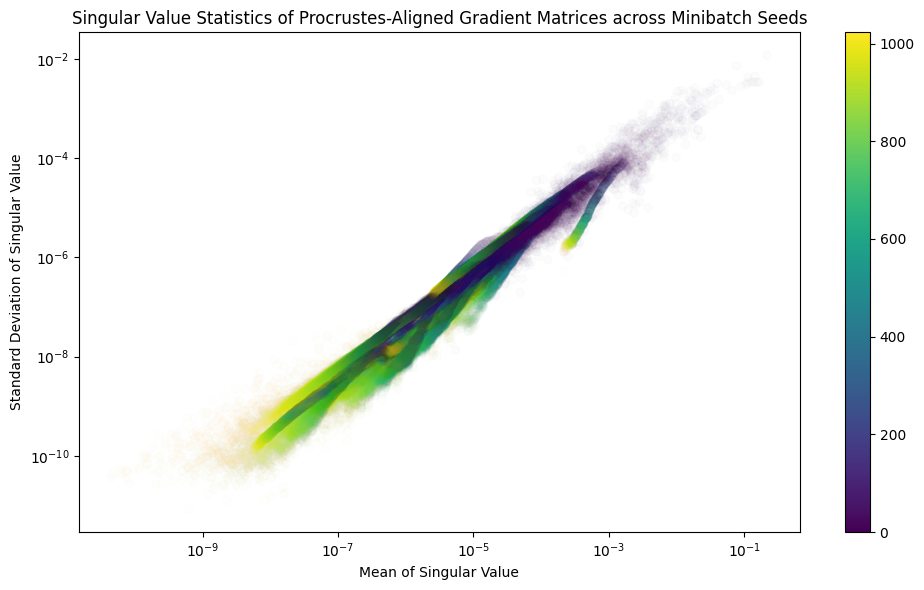

In [8]:
import numpy as np

# Create a figure and axes first
fig, ax = plt.subplots(figsize=(10, 6))

# Create the scatter plot on these axes
# scatter = ax.scatter(df['G_avg_singular_value'], df['mean/std'], 
                    # alpha=0.01, c=df['singular_value_index'])
# scatter = ax.scatter(df['G_avg_singular_value'], df['singular_value_variance'].apply(np.sqrt) / df['G_avg_singular_value'], 
#                     alpha=0.01, c=df['singular_value_index'])
scatter = ax.scatter(df['singular_value_mean'], df['singular_value_variance'].apply(np.sqrt), 
                    alpha=0.01, c=df['singular_value_index'])

# Set scales
ax.set_xscale('log')
ax.set_yscale('log')

# Add a colorbar with the scatter's colormap
cbar = fig.colorbar(scatter, ax=ax)
cbar.solids.set_alpha(1.0)  # Make the colorbar fully opaque

plt.title('Singular Value Statistics of Procrustes-Aligned Gradient Matrices across Minibatch Seeds')
plt.xlabel('Mean of Singular Value')
plt.ylabel('Standard Deviation of Singular Value')
plt.tight_layout()
plt.show()

/tmp/ipykernel_170197/3114980604.py:54: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


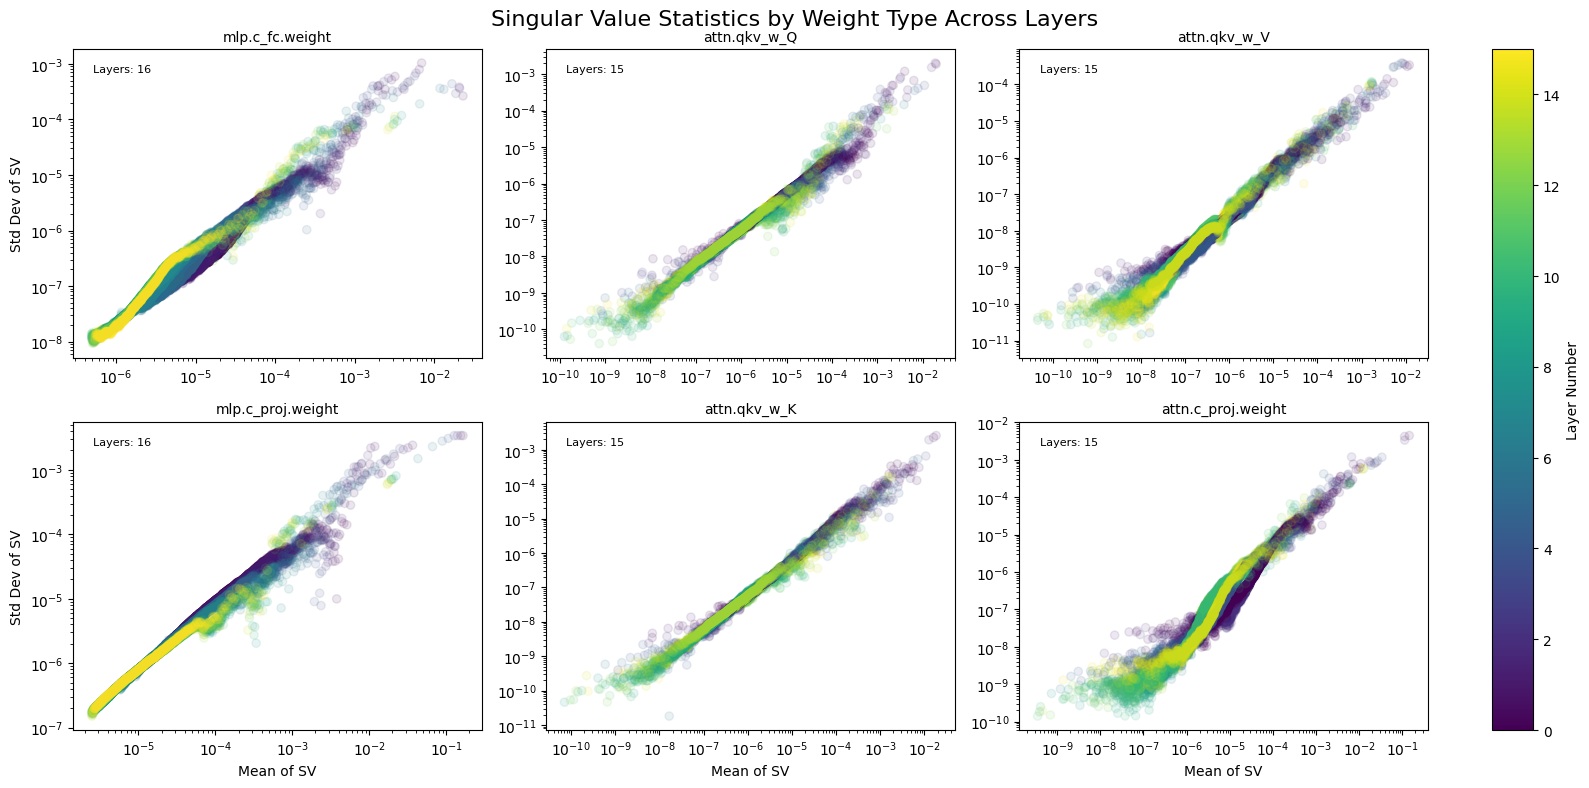

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import re
from matplotlib.colors import Normalize

# Process weight names to extract the type
def process_weight_name(name):
    # Check if it belongs to blocks
    if 'blocks' not in name:
        return None
    
    # Extract the type (everything after "blocks.N.")
    match = re.search(r'blocks\.\d+\.(.+)$', name)
    if match:
        return match.group(1)
    return None

# Apply the function to create a new column with processed weight names
df['weight_type'] = df['weight_name'].apply(process_weight_name)

# Filter out non-block weights
df_filtered = df[df['weight_type'].notna()]

# Get unique weight types
unique_weight_types = df_filtered['weight_type'].unique()
num_types = len(unique_weight_types)

# Calculate grid dimensions (try to make it approximately square)
num_cols = int(np.ceil(np.sqrt(num_types)))
num_rows = int(np.ceil(num_types / num_cols))

# Create a figure with subplots, leave room for colorbar on the right
fig = plt.figure(figsize=(5*num_cols + 1, 4*num_rows))
gs = fig.add_gridspec(num_rows, num_cols + 1, width_ratios=[1]*num_cols + [0.1])

# Create a list to hold all axes
axes = []
for i in range(num_rows):
    row_axes = []
    for j in range(num_cols):
        ax = fig.add_subplot(gs[i, j])
        row_axes.append(ax)
    axes.append(row_axes)

# Convert to NumPy array for easier indexing
axes = np.array(axes)
axes_flat = axes.flatten()

# Create a colormap for consistent coloring across subplots based on layer number
layer_min = df_filtered['layer_number'].min()
layer_max = df_filtered['layer_number'].max()
norm = Normalize(vmin=layer_min, vmax=layer_max)
cmap = plt.cm.get_cmap('viridis')

# Create a placeholder for the scatter plot object to use for the colorbar
scatter_for_cbar = None

# Create subplots for each weight type
for i, weight_type in enumerate(unique_weight_types):
    if i < len(axes_flat):  # Ensure we don't exceed the number of subplots
        ax = axes_flat[i]
        
        # Filter data for this weight type
        weight_df = df_filtered[df_filtered['weight_type'] == weight_type]
        
        # Create scatter plot colored by layer_number
        scatter = ax.scatter(weight_df['singular_value_mean'], 
                            weight_df['singular_value_variance'].apply(np.sqrt),
                            alpha=0.1, c=weight_df['layer_number'],
                            cmap=cmap, norm=norm)
        
        # Save the scatter object for the colorbar reference
        if scatter_for_cbar is None:
            scatter_for_cbar = scatter
        
        # Set scales
        ax.set_xscale('log')
        ax.set_yscale('log')
        
        # Add title and labels
        ax.set_title(f'{weight_type}', fontsize=10)
        
        # Add labels only to the leftmost and bottom subplots
        if i % num_cols == 0:  # Leftmost subplot in each row
            ax.set_ylabel('Std Dev of SV')
        if i >= num_cols * (num_rows - 1):  # Bottom row
            ax.set_xlabel('Mean of SV')
            
        # Add a count of the number of layers represented
        layer_count = len(weight_df['layer_number'].unique())
        ax.annotate(f'Layers: {layer_count}', xy=(0.05, 0.95), xycoords='axes fraction',
                   fontsize=8, ha='left', va='top')

# Hide any unused subplots
for j in range(i+1, len(axes_flat)):
    if j < len(axes_flat):
        axes_flat[j].set_visible(False)

# Add colorbar at the right side of the figure
if scatter_for_cbar is not None:
    cbar_ax = fig.add_subplot(gs[:, -1])  # Use the last column of gridspec for colorbar
    cbar = fig.colorbar(scatter_for_cbar, cax=cbar_ax)
    cbar.set_label('Layer Number')
    cbar.solids.set_alpha(1.0)  # Make the colorbar fully opaque

# Add an overall title
fig.suptitle('Singular Value Statistics by Weight Type Across Layers', fontsize=16)

# Adjust layout
plt.tight_layout()
fig.subplots_adjust(top=0.93)  # Adjust to make room for suptitle

plt.show()